# Inicialización de Páranetros.

## Introducción

* ***¿Qué significa inicializar parámetros?***
  - En una red neuronal, los parámetros son principalmente: `Pesos (weights)` y `Sesgos (biases)`.
  - `Inicializar` = darles valores iniciales antes de entrenar.
  - Aunque luego se ajustan con `backpropagation`, ***el punto de partida importa muchísimo***.

* ***¿Por qué NO usar números aleatorios “porque sí”?***.
  - Supón que inicializas los pesos así: `w ~ Uniform(-1, 1)`.
  - Al iniciar con este tipo de valores, las activaciones pueden explotar, es decir, tener valores enormes.
  - O también por su contrario casi desaparezcan, por ejemplo valores muy cercanos a 0.
  - Puede ocasionar queel gradiente se velva inútil (`vanishing/exploding gradients`).
  - El entrenamiento se vuelve lento o imposible.
* Esto pasa especialmente en redes profundas.
* Por eso no basta con “random”, necesitamos random inteligente.

* ***El problema central: la varianza***.
* Cuando una señal pasa por muchas capas:
  - Queremos que:
    - La varianza de la señal se mantenga estable.
    - Ni crezca ni se haga cero.
* ***Xavier y Kaiming nacen para resolver esto***.

* ***Xavier Initialization (Glorot) (Default)***.
  - Va más enfocada para las redes de tipo `sigmoide` o `tanh`.
  - Su idea clave es `mantener la varianza constante entre capas`.
  - Su formula está dada de la siguiente forma.
  - `fan_in` = número de entradas
  - `fan_out` = número de salidas.

$$\text{Var(w)} = \frac{2}{\text{fan\_in} + \text{fan\_out}}$$

  - Entonces lo valores que podrán seguir está dado por: `w ~ N(0, 2 / (fan_in + fan_out))`.
  - Esto funciona porque Sigmoid y tanh son simétricas.
  - Si los pesos son muy grandes → saturación.
  - Si son muy pequeños → señal débil.
  - `Xavier` mantiene el equilibrio.

* ***Kaiming He Initialization***.
  - Este tipo de optimización está más pensada para las redes `ReLU` y sus variantes `(Leaky ReLU, ELU)`.
  - *"ReLU mata la mitad de las neuronas (valores negativos → 0)"*.
  - ReLU mata la mitad de las neuronas (valores negativos → 0).
  - Por lo tanto estos datos seguirían algo como `w ~ N(0, 2 / fan_in)`.
  - Lo cuál nos puede dar Activaciones más estables.
  - Gradientes fuertes, lo que es ideal para redes profundas modernas.

* ***RESUMEN***.
| Inicialización   | Activación    | Ventaja            | Riesgo si se usa mal  |
| ---------------- | ------------- | ------------------ | --------------------- |
| Aleatoria simple | Cualquiera    | Fácil              | Exploding / Vanishing |
| Xavier           | tanh, sigmoid | Estable            | Débil con ReLU        |
| Kaiming He       | ReLU          | Profunda y robusta | Excesiva con sigmoid  |


## Antes de Xavier y Kaiming: ¿qué se hacía?.

* Antes se usaban Pesos pequeños aleatorios `w ~ Uniform(-0.01, 0.01)`.
* Lo que ocasionaba que todos sesgos con valores ceros.
* Pensaban *"Pequeños pesos = red estable; El gradiente ya se encargará"*.
* ***Esto no funcionaba bien para redes profundas***.

* ***Problema 1: simetría (el error más básico)***.
  - Si inicializamos todos los pesos iguales `w1 = w2 = w3 = ...`.
  - Entonces, todas las neuronas aprenden exactamente lo mismo.
  - La red es equivalente a tener una sola neurona.
  - Nunca se rompe la simetría.
  - Todos los pesos deben ser aleatorios.

* ***Problema 2: Vanishing Gradient***.
  - Imagina una red con sigmoid: `Entrada → sigmoid → sigmoid → sigmoid → salida`.
  - La Sigmoid aplasta todo a (0,1).
  - Su derivada máxima es cercano a `0.25`.
  - En el `backpropagation` multiplicas muchas derivadas < 1.
$$\nabla \approx 0.25^{L}$$
  - Entonces para una `L` grande, estos valores serán muy cercanos a cero.
  - ***Las capas iniciales no aprenden nada***.

* ***Problema 3: Exploding Gradient***.
  - Ahora pensemos en el caso contrario: Pesos grandes, Activaciones muy grandes, Derivadas Grandes.
  - Entonces durante el `backpropagation`:
$$\nabla \approx (\text{valor} > 1)^{L}$$
  - Lo que nos daría como resultado: Números enormes, NaNs y Entrenamiento inestable.

* ***El problema NO era el algoritmo de entrenamiento***.
* El verdadero problema: `La distribución de los valores se deforma al pasar capa por capa`.

* ***DUDAS***
* ¿Por qué es “malo” usar Uniforme? y ¿Y por qué antes se usaba?.
  - No es que la Uniforme sea mala, es que usar una Uniforme sin escala adecuada es el problema.
  - Antes se usaba porque su facilidad de implementación.
  - Computacional era muy barata.
  - No sé tenía noción del problema en la `propagación de varianza`.
  - Las redes no eran tan profundas.
  - Por lo tanto, no se consideraban muchas cosas que ahora son importantes.
  - Por ejemplo: `Entradas de la neurona, capas de la red y la función de activación`.

* Si todas las W son iguales… ¿realmente afecta tanto?
  - Si afecta, si ambas tiene lo mismo, producen la misma salida.
  - Los gradientes en ambas neuronas son iguales.
  - Se actualizan igual y ninca se diferencian.
  - ***Esto se llama no romper la simetría***.
  - No es “más difícil aprender” → es imposible aprender representaciones distintas.

* ¿Qué es “simetría”?
  - No es simetría de la distribución.
  - ***Simetría = neuronas indistinguibles***.
  - Dos neuronas son simétricas si: Tienen los mismos pesos, Reciben el mismo input, Usan la misma activación.
  - El algoritmo no tiene forma de saber cuál es cuál.

* ¿Qué es el Vanishing Gradient?
  - El gradiente se vuelve tan pequeño que el aprendizaje se detiene.
  - Principalmente por valores muy cercanos a 0.

* ¿Por qué la derivada máxima de sigmoid es 0.25?.

![DerivadaSigmoid.png](DerivadaSigmoid.png)

* ¿Cómo aparece el Exploding Gradient?

![Exploding.png](Exploding.png)

* ¿Qué son fan_in y fan_out?
  - NO son: `x`, `y`, `target`.
  - Son propiedades de la capa.
  - Para una capa densa: `fan_in = número de entradas`, `fan_out = número de neuronas`.

## ¿Cómo inicializamos en nuestra primera NN?

* Para nuestra primera ``NN no era un red de muchisimas capaz, es decir, es una ejemplo simple de como eran antes.
* Teníamos algo parecido a lo siguiente:
```python
    W1 = np.random.randn(neurons[0], input_size) * 0.001
    b1 = np.zeros((neurons[0], 1))

    W2 = np.random.randn(neurons[1], neurons[0]) * 0.001
    b2 = np.zeros((neurons[1], 1))
```
* Podemos ver nuestros pesos sipnaticos siguen una distribución normal con media de `0` y desviación de `1`.
* Vean que para que los datos sean aun más pequeños estos se multiplicaron por `0.001`.
* Directamente los `bias` se inicializan con ceros.
* Esto es justo lo que se expuso de las problematicas de hacer las inicializaciones de este tipo.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

-0.0006611694789726769 1.0005207652553465


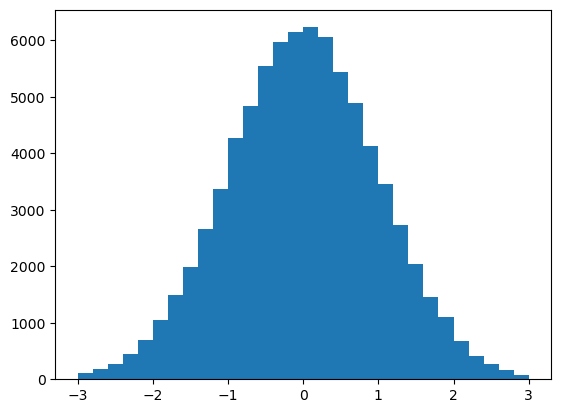

9.118521981354376e-08 0.0010003644577403323


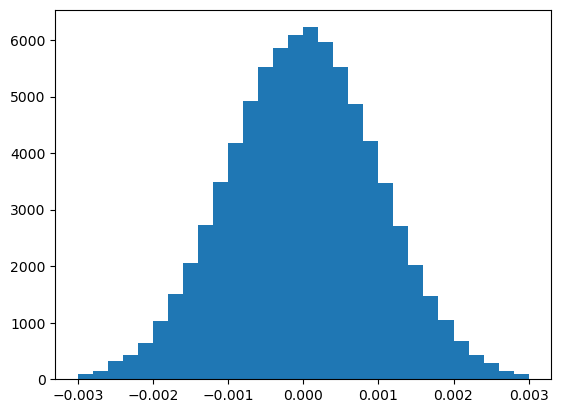

In [2]:
### Definimos una matriz de 100 * 784 con Medio 0 y Desviación de 1.
W = np.random.randn(100,784)
print(W.mean(), W.std())

### Imprimimos los valores
plt.figure()
plt.hist(W.ravel(), bins=30, range=[-3,3])
plt.show()

W2 = np.random.randn(100,784) * 0.001
print(W2.mean(), W2.std())

### Imprimimos los valores
plt.figure()
plt.hist(W2.ravel(), bins=30, range=[-0.003,0.003])
plt.show()

## Funciones para cargar imagenes MNIST

In [3]:
import gzip
import os
from os.path import isfile, join
from contextlib import contextmanager
import zipfile

### Tener cuidado con el formato de windows
mnist_path = "C:\\Users\\PC\\OneDrive\\Documentos\\MNIST"

def getListFiles(mnist_path : str) -> list:
    return [
        join(mnist_path, file) 
        for file in os.listdir(mnist_path) 
        if isfile(join(mnist_path, file))
    ]


@contextmanager
def open_mnist_file(path: str):
    """
    Abre archivos MNIST en formato:
    - .gz
    - .zip
    - sin comprimir (.idx*-ubyte)
    Devuelve un stream binario.
    """
    if path.endswith(".gz"):
        f = gzip.open(path, "rb")
        try:
            yield f
        finally:
            f.close()

    elif path.endswith(".zip"):
        zf = zipfile.ZipFile(path)
        try:
            inner_name = zf.namelist()[0]
            with zf.open(inner_name) as f:
                yield f
        finally:
            zf.close()

    else:
        with open(path, "rb") as f:
            yield f


def _read_int32_be(f) -> int:
    """Lee un entero de 32 bits big-endian."""
    return int.from_bytes(f.read(4), byteorder="big")


def _read_images(f):
    """Lee un archivo idx3-ubyte (imágenes)."""
    _ = _read_int32_be(f)          # magic number
    num_images = _read_int32_be(f)
    rows = _read_int32_be(f)
    cols = _read_int32_be(f)

    data = f.read()
    images = np.frombuffer(data, dtype=np.uint8)
    return images.reshape(num_images, rows, cols)


def _read_labels(f):
    """Lee un archivo idx1-ubyte (labels)."""
    _ = _read_int32_be(f)  # magic number
    _ = _read_int32_be(f)  # número de labels
    return np.frombuffer(f.read(), dtype=np.uint8)


def getImages(files: list[str]):
    x_train = y_train = x_test = y_test = None

    for path in files:
        with open_mnist_file(path) as f:

            if "train-images" in path:
                x_train = _read_images(f)

            elif "train-labels" in path:
                y_train = _read_labels(f)

            elif "t10k-images" in path:
                x_test = _read_images(f)

            elif "t10k-labels" in path:
                y_test = _read_labels(f)

    return x_train, y_train, x_test, y_test

files = getListFiles(mnist_path)

## Separación conjuntos de datos train y test.

* Una vez extraido los datos, podemos ver como antiguamente nosotros teníamos esto:
* `x_train = x_train_num[:50000].reshape(50000, -1).astype(np.float32)/255`.
* Pero ahora ya no son dividios entre `255`.
* Antes era como una mini-especie de función `Min-Max` y tener los valores entre el rango `[0,1]`.

* ***¿Qué significa ahora “normalizar” con una función?***
  - Cuando vemos `(x_data-x_mean)/x_std)`, estamos haciendo una `normalización estándar (z-score)`.
  - Esto para que tenga una media cercana a 0 y una desviación cercana a 1.

* ***¿Por qué esto es mejor que solo dividir por 255?***
  - Dividir por 255: Escala los valores pero No centra los datos.
  - Normalización estándar: Escala, Centra en 0, Reduce sesgos entre features, Ayuda muchísimo a la convergencia.

* Esto conecta directamente con tu tema de inicialización.
* Inicializaciones como: `Xavier / Glorot` y `He`.
* Ya que estas asumen que las entradas están centradas y normalizadas.
* Si no lo están:
  - Activaciones pueden saturarse (sigmoid/tanh).
  - Gradientes pueden explotar o desaparecer.
  - Da igual que tan buena sea la inicialización.
* Una buena inicialización necesita datos bien normalizados para funcionar como fue diseñada.

In [4]:
x_train_num, y_train_num, x_test_num, y_test_num = getImages(files)

### Datos de entrenamiento
x_train = x_train_num[:50000].reshape(50000, -1).astype(np.float32)
y_train = y_train_num[:50000].reshape(50000, 1)

### Datos de validación (los ultimos 10k)
x_val = x_train_num[50000:].reshape(10000, -1).astype(np.float32)
y_val = y_train_num[50000:].reshape(10000, 1)

### Datos de prueba (origialmente ya son 10k, solo se pasaron a vector)
x_test = x_test_num.copy().reshape(10000, -1).astype(np.float32)
y_test = y_test_num.copy().reshape(10000, 1)

In [5]:
def normalise(x_mean, x_std, x_data):
    return (x_data-x_mean)/x_std

In [6]:
x_t = normalise(x_train[:128].mean(), x_train[:128].std(), x_train[:128])
x_t.min(), x_t.max(), x_t.mean(), x_t.std()

(-0.4187288, 2.8666344, -2.0223004e-08, 1.0)

## Graficar muestras

La imagen mostrada corresponde a un : 9


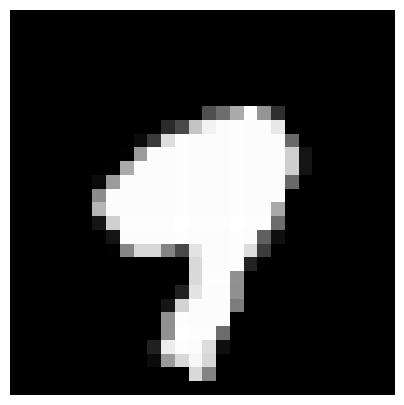

In [7]:
def plot_number(image):
    plt.figure(figsize=(5,5))
    plt.imshow(image.squeeze(), cmap=plt.get_cmap('gray'))
    plt.axis('off')
    plt.show()

rnd_idx = np.random.randint(len(y_test))
print(f'La imagen mostrada corresponde a un : {y_test[rnd_idx][0]}')
plot_number(x_test_num[rnd_idx])

## Inicialización de pesos sinápticos con Valores aleatorios, Xavier y Kaiming He

* Cuando hablamos de la formula de `Xavier` y `Harming`, más que nada son estás de la `varianza`:
$$\text{Var Xavier}(W) = \frac{1}{n_{in}}$$
$$\text{Var He}(W) = \frac{2}{n_{in}}$$
* No nos está diciendo que cada peso vale $\frac{1}{n_{in}}$, lo que realmente nos dice, es que los pesos deben venir de una distribución cuya varianza siga ese estilo de forma.
* ***Lo importante es cómo se distribuyen en conjunto, no su valor exacto***.
* Ahora entendido este punto, empecemos a revisar el código proporcionado.
* Cuando usamos `np.random.randn(...)`, estamos generando datos con distribución normal.
* Este es el punto de partida de todas las inicializaciones.

* ***La pieza que falta: cómo se cambia la varianza***
* En código cuando hacemos `np.random.randn(neurons[i+1], neurons[i]) / np.sqrt(neurons[i])`.

| Imagen A | Imagen B |
| :---: | :---: |
| ![VarianzaDesvNormal.png](VarianzaDesvNormal.png) | ![ObtenciónXavier.png](ObtenciónXavier.png) |

* Lo mismo para con `He`, `np.random.randn(...) / np.sqrt(neurons[i] / 2)`.

| Imagen A | Imagen B |
| :---: | :---: |
| ![DesviacionHe.png](DesviacionHe.png) | ![ObtencionHe.png](ObtencionHe.png) |

* ***Las fórmulas hablan de varianza. El código implementa la desviación estándar.***

* ***DUDAS***
* ¿Por qué la varianza de $Y = a \cdot X = a^{2}$? ¿Qué es ese "a"?
  - `X` es una variable aletoria por ejemplo ` np.random.randn`.
  - `a` es un núero constante, no aleatorio. `(1/√n_in), (√(2/n_in))`.
* En inicialización de pesos:
```python
a = 1 / np.sqrt(n_in)       # Xavier
a = np.sqrt(2 / n_in)       # He
```
* Algebra básica:

![AlgebraBasica.png](AlgebraBasica.png)

In [12]:
# Obtención de las desviaciones estándar.

### Inicialización normal
def init_params(neurons):
    weights = {}
    for i in range(len(neurons)-1):
        weights['L' + str(i+1)] = np.random.randn(neurons[i+1], neurons[i]) * 0.001
    return weights 

### Inicialización Xavier.
def init_xavier(neurons):
    weights = {}
    for i in range(len(neurons)-1):
        weights['L' + str(i+1)] = np.random.randn(neurons[i+1], neurons[i]) / np.sqrt(neurons[i])
    return weights 
    
### Inicialización He
def init_kaiming(neurons):
    weights = {}
    for i in range(len(neurons)-1):
        weights['L' + str(i+1)] = np.random.randn(neurons[i+1], neurons[i]) / np.sqrt(neurons[i]/2)
    # return weights 

## Definir algunas capas

In [10]:
### una lista de 10 500's
neurons = [500] * 10

### La primera intrada serán 784 datos de la imagen 28x28
neurons[0] = 784

### La última capa serán los 10 posibles casos.
neurons[-1] = 10

print(neurons)

[784, 500, 500, 500, 500, 500, 500, 500, 500, 10]


## Inicializar parámetros

In [20]:
weights = init_params(neurons)
weights_x = init_xavier(neurons)
weights_k = init_kaiming(neurons)
print(weights_k.keys())
### Input de 784 y 500 neuronas.
print(weights_k['L1'].shape)

dict_keys(['L1', 'L2', 'L3', 'L4', 'L5', 'L6', 'L7', 'L8', 'L9'])
(500, 784)


## Pruebas con Random Init

* Visto lo visto hasta ahora, ahora lo que queremos revisar es como se comporta la ***variabilidad*** en todas nuestras capas.
* Es decir, para evitar lo del `vanishing gradient`.
* Recordemos el valor de `xt` --> `x_t = normalise(x_train[:128].mean(), x_train[:128].std(), x_train[:128])`.
* En este primer caso `weights` tiene la inicialización que se hacía en el 2010.

In [21]:
acts = {}
z = x_t.T
for (k, v) in weights.items():
    z = v @ z
    #z = no.maximum(0,z) #ReLU
    acts[k] = z

print(acts.keys())

dict_keys(['L1', 'L2', 'L3', 'L4', 'L5', 'L6', 'L7', 'L8', 'L9'])


* Podemos ver como para la inicialización `antigua`, los valores mientras más pasan capas estos valores son muy pequeños.
* Igualmente vemos como su desviación estandar es demasiada cercana a cero.
* Esto afecto muy gravemente al `gradiente`, ya que el aprendizaje sería `0`.
* Inclusive podemos ver como solo en la primeras capas hay una gran variación, despues, todas son iguales.
* Veamos esto con sus ecuación matemáticas.

![VanishingGradient.png](VanishingGradient.png)


La Actividad para la capa L1     tiene una media de 0.000616 y una std de 0.02844
La Actividad para la capa L2     tiene una media de -2.187e-05 y una std de 0.0006346
La Actividad para la capa L3     tiene una media de -2.749e-07 y una std de 1.409e-05
La Actividad para la capa L4     tiene una media de 3.105e-09 y una std de 3.038e-07
La Actividad para la capa L5     tiene una media de 1.098e-10 y una std de 6.862e-09
La Actividad para la capa L6     tiene una media de 7.555e-12 y una std de 1.551e-10
La Actividad para la capa L7     tiene una media de -8.524e-14 y una std de 3.511e-12
La Actividad para la capa L8     tiene una media de 7.863e-16 y una std de 7.764e-14
La Actividad para la capa L9     tiene una media de -7.816e-17 y una std de 1.783e-15


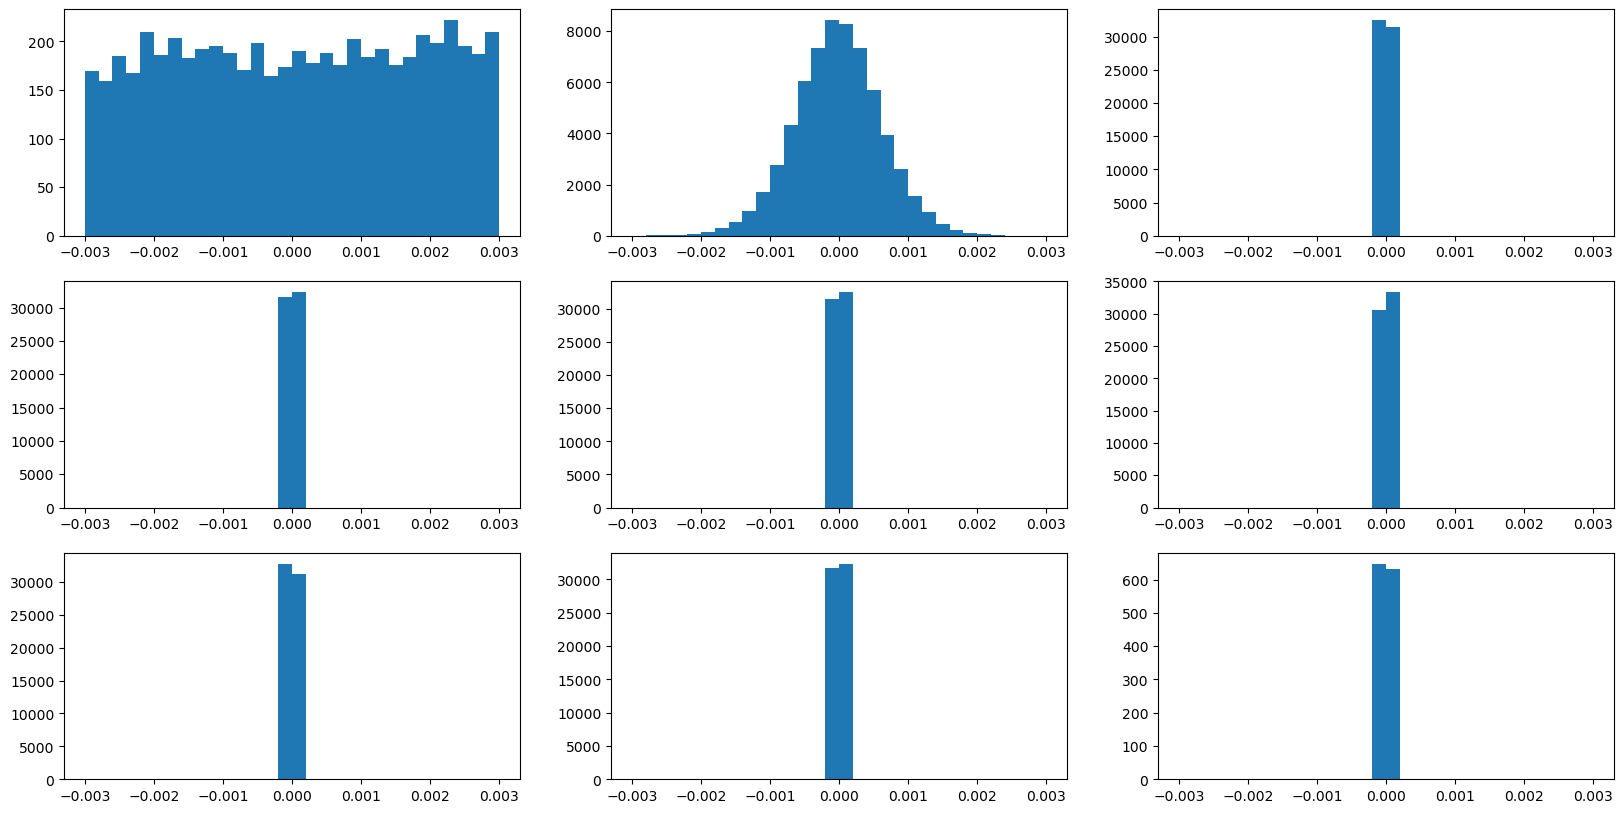

In [26]:
plt.figure(figsize=(20,10))

for i, (k, v) in enumerate(acts.items()):
    print(f'La Actividad para la capa {k} \
    tiene una media de {v.ravel().mean():.4} y una std de {v.ravel().std():.4}')

for i, (k, v) in enumerate(acts.items(), 1):
    plt.subplot(3,3,i)
    plt.hist(v.ravel(),bins=30, range=[-0.003, 0.003])

plt.show()

## Pruebas Con Xavier Init

In [36]:
acts = {}
z = x_t.T
for (k, v) in weights_x.items():
    z = v @ z
    # z = np.maximum(0,z) #ReLU
    # z = np.tanh(z) #Tangente Hiperbolica
    # z = 1/(1+np.exp(-z)) #Sigmoid
    acts[k] = z

print(acts.keys())

dict_keys(['L1', 'L2', 'L3', 'L4', 'L5', 'L6', 'L7', 'L8', 'L9'])


La Actividad para la capa L1     tiene una media de 0.02785 y una std de 1.005
La Actividad para la capa L2     tiene una media de -0.02521 y una std de 1.004
La Actividad para la capa L3     tiene una media de -0.03087 y una std de 0.998
La Actividad para la capa L4     tiene una media de 0.0268 y una std de 0.9791
La Actividad para la capa L5     tiene una media de -0.01276 y una std de 0.9867
La Actividad para la capa L6     tiene una media de 0.02909 y una std de 0.9899
La Actividad para la capa L7     tiene una media de 0.01355 y una std de 0.9728
La Actividad para la capa L8     tiene una media de -0.04487 y una std de 0.9604
La Actividad para la capa L9     tiene una media de -0.1082 y una std de 1.071


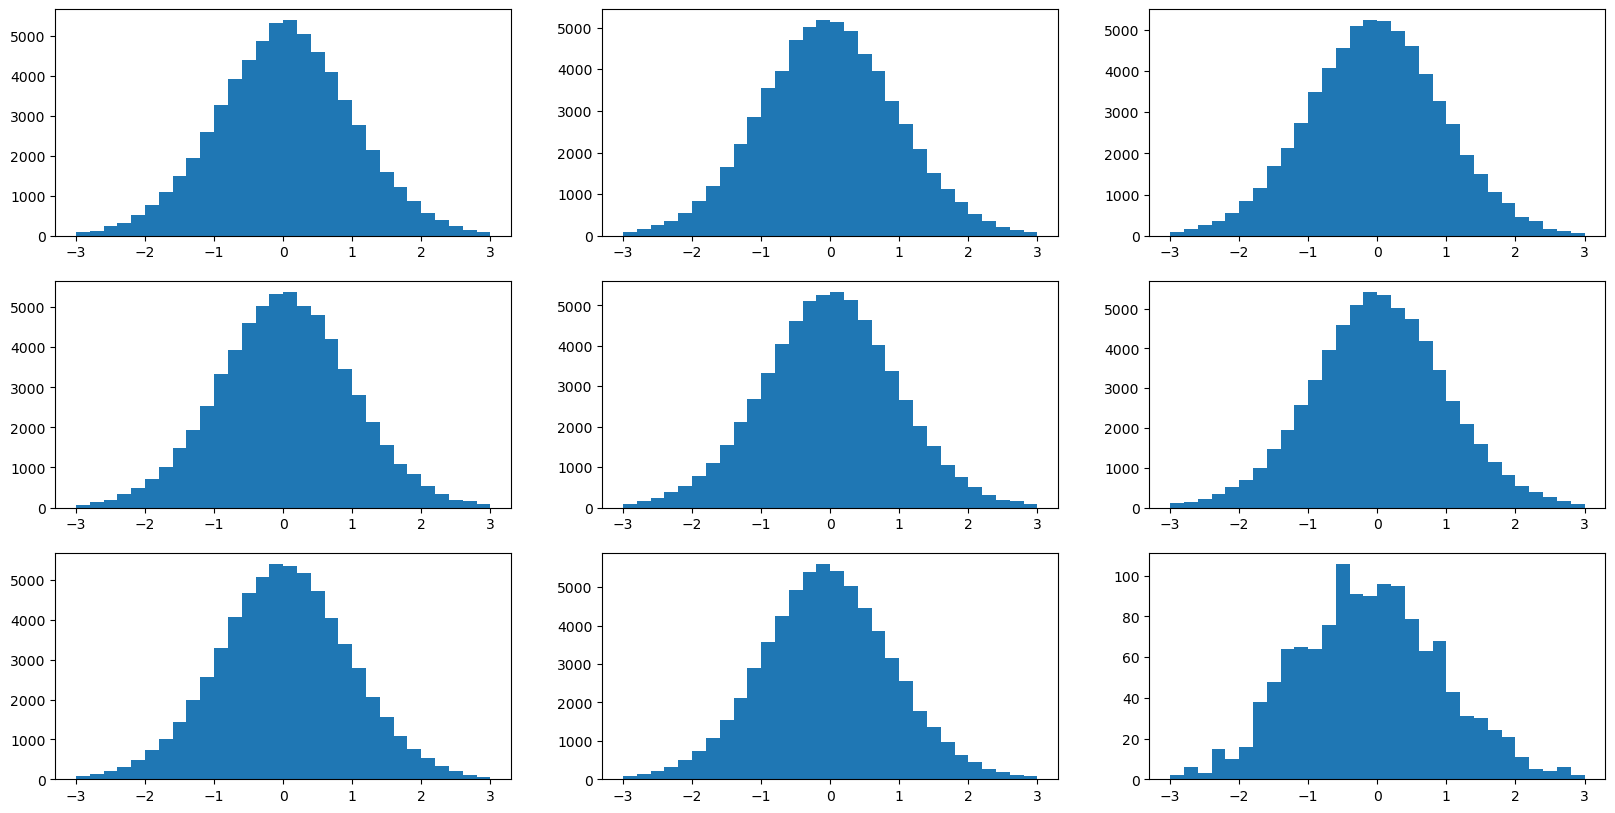

In [35]:
plt.figure(figsize=(20,10))

for i, (k, v) in enumerate(acts.items()):
    print(f'La Actividad para la capa {k} \
    tiene una media de {v.ravel().mean():.4} y una std de {v.ravel().std():.4}')

for i, (k, v) in enumerate(acts.items(), 1):
    plt.subplot(3,3,i)
    plt.hist(v.ravel(),bins=30, range=[-3, 3])

plt.show()

## Pruebas con Ke Init

In [37]:
acts = {}
z = x_t.T
for (k, v) in weights_k.items():
    z = v @ z
    # z = np.maximum(0,z) #ReLU
    # z = np.tanh(z) #Sigmoid
    # z = 1/(1+np.exp(-z))
    acts[k] = z

print(acts.keys())

dict_keys(['L1', 'L2', 'L3', 'L4', 'L5', 'L6', 'L7', 'L8', 'L9'])


La Actividad para la capa L1     tiene una media de 0.008546 y una std de 1.383
La Actividad para la capa L2     tiene una media de -0.006334 y una std de 1.959
La Actividad para la capa L3     tiene una media de 0.02022 y una std de 2.831
La Actividad para la capa L4     tiene una media de 0.03794 y una std de 3.904
La Actividad para la capa L5     tiene una media de -0.02001 y una std de 5.505
La Actividad para la capa L6     tiene una media de 0.1508 y una std de 7.654
La Actividad para la capa L7     tiene una media de 0.1835 y una std de 10.95
La Actividad para la capa L8     tiene una media de -0.2785 y una std de 15.34
La Actividad para la capa L9     tiene una media de 0.6642 y una std de 18.61


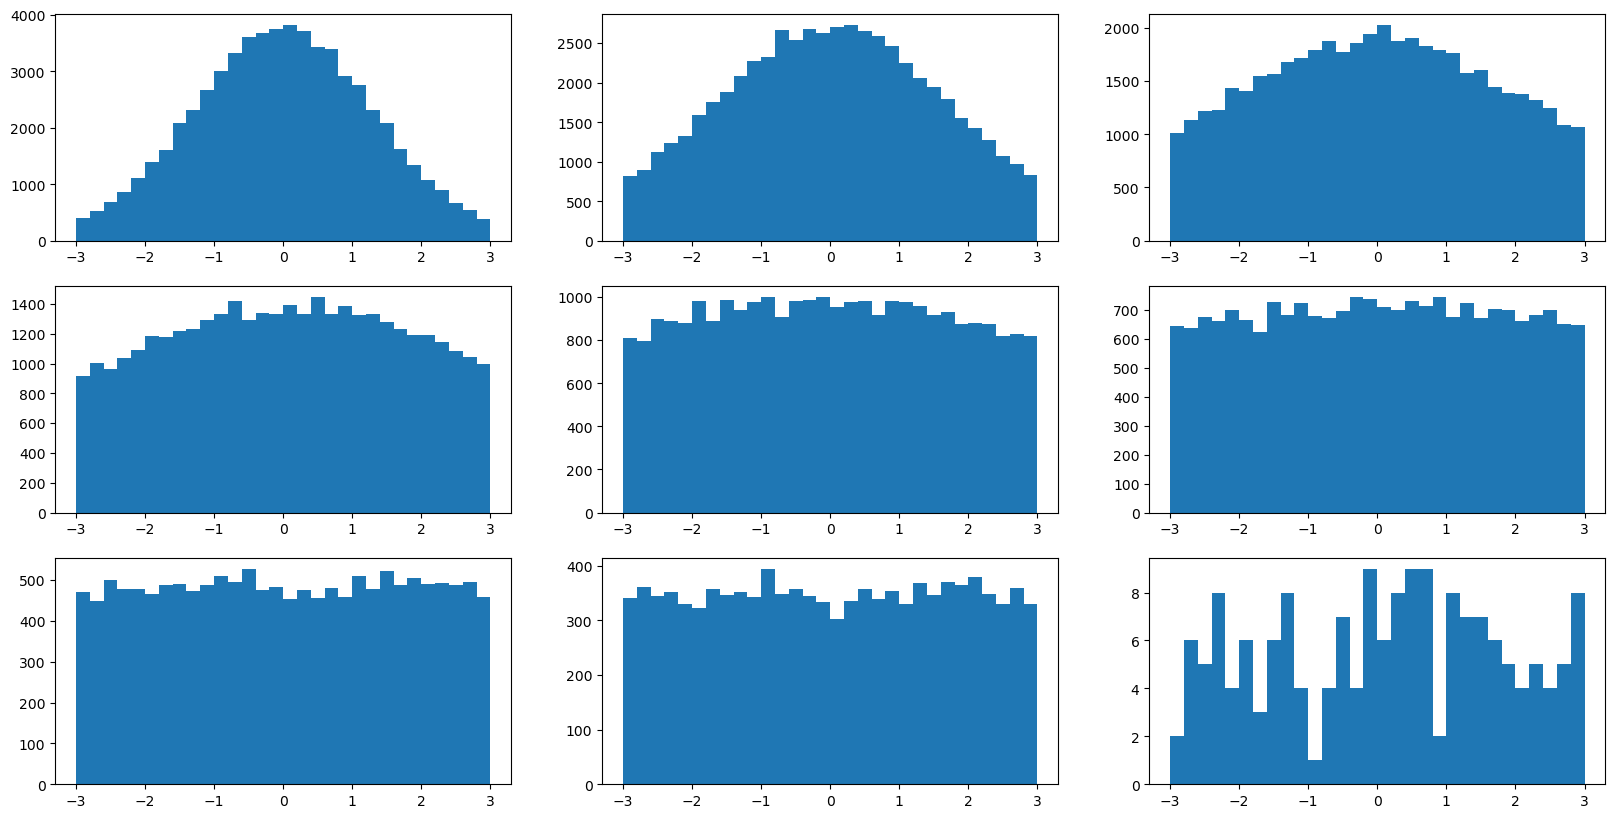

In [39]:
plt.figure(figsize=(20,10))

for i, (k, v) in enumerate(acts.items()):
    print(f'La Actividad para la capa {k} \
    tiene una media de {v.ravel().mean():.4} y una std de {v.ravel().std():.4}')

for i, (k, v) in enumerate(acts.items(), 1):
    plt.subplot(3,3,i)
    plt.hist(v.ravel(),bins=30, range=[-3, 3])

plt.show()